# 01 DATA CLEANING

In [1]:
import pandas as pd

results = pd.read_csv('../data/raw/results.csv')
status = pd.read_csv('../data/raw/status.csv')
races = pd.read_csv('../data/raw/races.csv')
drivers = pd.read_csv('../data/raw/drivers.csv')
constructors = pd.read_csv('../data/raw/constructors.csv')
qualifying = pd.read_csv('../data/raw/qualifying.csv')
circuits = pd.read_csv('../data/raw/circuits.csv')
driver_standings = pd.read_csv('../data/raw/driver_standings.csv')
constructor_standings = pd.read_csv('../data/raw/constructor_standings.csv')

print("results:", results.shape)
print("status:", status.shape)
print("races:", races.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)
print("qualifying:", qualifying.shape)
print("circuits:", circuits.shape)
print("driver_standings:", driver_standings.shape)
print("constructor_standings:", constructor_standings.shape)

results: (26759, 18)
status: (139, 2)
races: (1125, 18)
drivers: (861, 9)
constructors: (212, 5)
qualifying: (10494, 9)
circuits: (77, 9)
driver_standings: (34863, 7)
constructor_standings: (13391, 7)


### 01.01 DROP DUPLICATE COLUMN

In [2]:
results = results.drop(columns=['url'], errors='ignore')
status = status.drop(columns=['url'], errors='ignore')
races = races.drop(columns=['url'], errors='ignore')
drivers = drivers.drop(columns=['url'], errors='ignore')
constructors = constructors.drop(columns=['url'], errors='ignore')
qualifying = qualifying.drop(columns=['url'], errors='ignore')
circuits = circuits.drop(columns=['url'], errors='ignore')
driver_standings = driver_standings.drop(columns=['url'], errors='ignore')
constructor_standings = constructor_standings.drop(columns=['url'], errors='ignore')



print("results:", results.shape)
print("status:", status.shape)
print("races:", races.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)
print("qualifying:", qualifying.shape)
print("circuits:", circuits.shape)
print("driver_standings:", driver_standings.shape)
print("constructor_standings:", constructor_standings.shape)

results: (26759, 18)
status: (139, 2)
races: (1125, 17)
drivers: (861, 8)
constructors: (212, 4)
qualifying: (10494, 9)
circuits: (77, 8)
driver_standings: (34863, 7)
constructor_standings: (13391, 7)


### 01.02 RENAME COLUMNS WITH SAME NAMES IN DIFFERENT TABLE

In [3]:


results_clean = results[['resultId', 'raceId', 'driverId', 'constructorId', 
                          'grid', 'position', 'positionOrder', 'points', 
                          'laps', 'statusId', 'fastestLap', 'rank', 
                          'fastestLapTime', 'fastestLapSpeed']]

races_clean = races[['raceId', 'circuitId', 'name', 'year', 'round', 'date']]
races_clean = races_clean.rename(columns={'name': 'race_name'})

circuits_clean = circuits[['circuitId', 'circuitRef', 'country', 'lat', 'lng']]

drivers_clean = drivers[['driverId', 'driverRef', 'forename', 'surname', 
                          'nationality', 'dob']]
drivers_clean = drivers_clean.rename(columns={'forename': 'driver_forename', 
                                                  'surname': 'driver_surname', 
                                                  'nationality': 'driver_nationality'})

constructors_clean = constructors[['constructorId', 'constructorRef', 
                                   'name', 'nationality']]
constructors_clean = constructors_clean.rename(columns={'name': 'constructor_name', 
                                                         'nationality': 'constructor_nationality'})

qualifying_clean = qualifying[['raceId', 'driverId', 'number', 'position']]
qualifying_clean = qualifying_clean.rename(columns={'position': 'qualifying_position',
                                                     'number': 'driver_number'})

status_clean = status[['statusId', 'status']]

driver_standings_clean = driver_standings[['raceId', 'driverId', 'points', 'position', 'wins']]
driver_standings_clean = driver_standings_clean.rename(columns={'points': 'driver_championship_points',
                                                                 'position': 'driver_championship_position',
                                                                 'wins': 'driver_wins'})

constructor_standings_clean = constructor_standings[['raceId', 'constructorId', 'points', 'position', 'wins']]
constructor_standings_clean = constructor_standings_clean.rename(columns={'points': 'constructor_championship_points',
                                                                           'position': 'constructor_championship_position',
                                                                           'wins': 'constructor_wins'})

### 01.03 MERGE TABLE WITH RESULT TABLE

In [4]:
df = pd.merge(results_clean, races_clean, on='raceId', how='left')
df = pd.merge(df, circuits_clean, on='circuitId', how='left')
df = pd.merge(df, drivers_clean, on='driverId', how='left')
df = pd.merge(df, constructors_clean, on='constructorId', how='left')
df = pd.merge(df, qualifying_clean, on=['raceId', 'driverId'], how='left')
df = pd.merge(df, status_clean, on='statusId', how='left')
df = pd.merge(df, driver_standings_clean, on=['raceId', 'driverId'], how='left', suffixes=('', '_driver_standing'))
df = pd.merge(df, constructor_standings_clean, on=['raceId', 'constructorId'], how='left', suffixes=('', '_constructor_standing'))

In [5]:

print(df.columns.tolist())
print(df.shape)

['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position', 'positionOrder', 'points', 'laps', 'statusId', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'circuitId', 'race_name', 'year', 'round', 'date', 'circuitRef', 'country', 'lat', 'lng', 'driverRef', 'driver_forename', 'driver_surname', 'driver_nationality', 'dob', 'constructorRef', 'constructor_name', 'constructor_nationality', 'driver_number', 'qualifying_position', 'status', 'driver_championship_points', 'driver_championship_position', 'driver_wins', 'constructor_championship_points', 'constructor_championship_position', 'constructor_wins']
(26759, 40)


### 01.04 DNF column

In [6]:
# check these
print(df[df['status'].isin(['Did not qualify', 'Did not prequalify', 'Withdrew', 'Not classified'])]['status'].value_counts())

status
Did not qualify       1025
Did not prequalify     331
Withdrew               248
Not classified         172
Name: count, dtype: int64


In [7]:

finished_statuses = df[df['status'].str.contains(r'^\+\d+ Lap', regex=True)]['statusId'].unique().tolist()
finished_statuses.append(1)  # add "Finished" statusId

df['DNF'] = (~df['statusId'].isin(finished_statuses)).astype(int)

print(df['DNF'].value_counts(normalize=True))

DNF
0    0.566576
1    0.433424
Name: proportion, dtype: float64


In [8]:
remove_statuses = ['Did not qualify', 'Did not prequalify', 'Withdrew', 'Excluded']
df = df[~df['status'].isin(remove_statuses)]

print(df.shape)
print(df['DNF'].value_counts(normalize=True))

(25147, 41)
DNF
0    0.602895
1    0.397105
Name: proportion, dtype: float64


# 02 FEATURE ENGG

In [9]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['DNF'].sort_values(ascending=False))

DNF                                  1.000000
positionOrder                        0.728541
statusId                             0.358621
driver_championship_position         0.308186
constructor_championship_position    0.212985
grid                                 0.148657
qualifying_position                  0.145851
circuitId                            0.014367
lat                                  0.006976
constructorId                        0.006389
driver_number                       -0.045565
lng                                 -0.073312
round                               -0.103693
driverId                            -0.105852
constructor_wins                    -0.123667
driver_wins                         -0.127062
raceId                              -0.139860
resultId                            -0.151671
constructor_championship_points     -0.194495
driver_championship_points          -0.199913
year                                -0.245855
points                            

### Create a column for driver_experience

cumcount() is simpler than rolling — it just counts how many rows have appeared so far for each group:

In [10]:
df = df.sort_values(['driverId', 'date'])

df['driver_experience'] = df.groupby('driverId').cumcount()

print(df['driver_experience'].describe())
print(df['driver_experience'].isnull().sum())

count    25147.000000
mean        66.966835
std         68.853487
min          0.000000
25%         14.000000
50%         44.000000
75%         98.000000
max        401.000000
Name: driver_experience, dtype: float64
0


### 02.01 constructor_dnf_rate_last20

<Axes: title={'center': 'DNF Rate by Year'}, xlabel='year'>

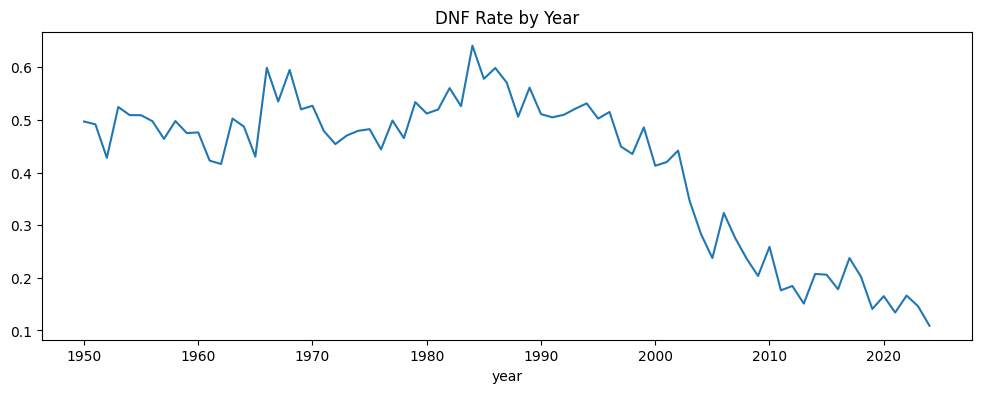

In [11]:
df.groupby('year')['DNF'].mean().plot(kind='line', figsize=(12,4), title='DNF Rate by Year')

This graphs shows that DNF rates dropped significantly after 2010 era it was due the masssive regulation changes. This means using data from before 2010 would not be relevant as our model will learn unncesssary information which would not give us right outputs.

In [12]:
df = df[df['year'] >= 2014]
print(df.shape)
print(df['DNF'].value_counts(normalize=True))

(4611, 42)
DNF
0    0.829538
1    0.170462
Name: proportion, dtype: float64


The data is imbalanced as DNF rates are low and Finished rates are High. There is nothing that can be done because F1 cars have become reliable after 2010. 
Only way to evaluate our model is to not use Accuracy_Score but use F1 score or ROC-AUC 

In [13]:
print(df.shape)

(4611, 42)


In [14]:
df = df.sort_values(['constructorId', 'date'])

In [15]:
df['constructor_dnf_rate'] = df.groupby('constructorId')['DNF'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=1).mean()
    )

df['constructor_dnf_rate'] = df['constructor_dnf_rate'].fillna(0.28)

print(df['constructor_dnf_rate'].describe())
print(df['constructor_dnf_rate'].isnull().sum())

count    4611.000000
mean        0.173226
std         0.118754
min         0.000000
25%         0.100000
50%         0.150000
75%         0.250000
max         1.000000
Name: constructor_dnf_rate, dtype: float64
0


In [16]:
df['constructor_dnf_rate_last10'] = df.groupby('constructorId')['DNF'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
    )

df['constructor_dnf_rate_last10'] = df['constructor_dnf_rate_last10'].fillna(0.28)

print(df['constructor_dnf_rate_last10'].describe())
print(df['constructor_dnf_rate_last10'].isnull().sum())

count    4611.000000
mean        0.172194
std         0.142267
min         0.000000
25%         0.100000
50%         0.166667
75%         0.280000
max         1.000000
Name: constructor_dnf_rate_last10, dtype: float64
0


In [17]:
df['constructor_dnf_rate_last5'] = df.groupby('constructorId')['DNF'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

df['constructor_dnf_rate_last5'] = df['constructor_dnf_rate_last5'].fillna(0.28)

print(df['constructor_dnf_rate_last5'].describe())
print(df['constructor_dnf_rate_last5'].isnull().sum())

count    4611.000000
mean        0.171644
std         0.182696
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         1.000000
Name: constructor_dnf_rate_last5, dtype: float64
0


### 02.02 driver_dnf_rate_last20 and last10

In [18]:
df = df.sort_values(['driverId', 'date'])

In [19]:
df['driver_dnf_rate'] = df.groupby('driverId')['DNF'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=1).mean()
    )

df['driver_dnf_rate'] = df['driver_dnf_rate'].fillna(0.28)

print(df['driver_dnf_rate'].describe())
print(df['driver_dnf_rate'].isnull().sum())

count    4611.000000
mean        0.178216
std         0.127988
min         0.000000
25%         0.100000
50%         0.150000
75%         0.250000
max         1.000000
Name: driver_dnf_rate, dtype: float64
0


In [20]:
df['driver_dnf_rate_last10'] = df.groupby('driverId')['DNF'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
    )

df['driver_dnf_rate_last10'] = df['driver_dnf_rate_last10'].fillna(0.28)

print(df['driver_dnf_rate_last10'].describe())
print(df['driver_dnf_rate_last10'].isnull().sum())

count    4611.000000
mean        0.174672
std         0.146709
min         0.000000
25%         0.100000
50%         0.200000
75%         0.280000
max         1.000000
Name: driver_dnf_rate_last10, dtype: float64
0


In [21]:
df['driver_dnf_rate_last5'] = df.groupby('driverId')['DNF'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

df['driver_dnf_rate_last5'] = df['driver_dnf_rate_last5'].fillna(0.28)

print(df['driver_dnf_rate_last5'].describe())
print(df['driver_dnf_rate_last5'].isnull().sum())

count    4611.000000
mean        0.172382
std         0.182036
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         1.000000
Name: driver_dnf_rate_last5, dtype: float64
0


Checking mean min max for driver exp after filtering 2010

In [22]:
print(df['driver_experience'].describe())
print(df['driver_experience'].isnull().sum())

count    4611.000000
mean      118.422251
std        92.662725
min         0.000000
25%        40.000000
50%        97.000000
75%       180.000000
max       401.000000
Name: driver_experience, dtype: float64
0


In [23]:
df.columns.tolist() 

['resultId',
 'raceId',
 'driverId',
 'constructorId',
 'grid',
 'position',
 'positionOrder',
 'points',
 'laps',
 'statusId',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'circuitId',
 'race_name',
 'year',
 'round',
 'date',
 'circuitRef',
 'country',
 'lat',
 'lng',
 'driverRef',
 'driver_forename',
 'driver_surname',
 'driver_nationality',
 'dob',
 'constructorRef',
 'constructor_name',
 'constructor_nationality',
 'driver_number',
 'qualifying_position',
 'status',
 'driver_championship_points',
 'driver_championship_position',
 'driver_wins',
 'constructor_championship_points',
 'constructor_championship_position',
 'constructor_wins',
 'DNF',
 'driver_experience',
 'constructor_dnf_rate',
 'constructor_dnf_rate_last10',
 'constructor_dnf_rate_last5',
 'driver_dnf_rate',
 'driver_dnf_rate_last10',
 'driver_dnf_rate_last5']

### 02.03 circuit_dnf_rate

F1 circuits keep changes. The corner change, places that have been notes for causing risk of accidents are changed in new regulations, so instead of using expanding data we will use rolling 10

In [24]:
df['circuit_dnf_rate'] = df.groupby('circuitId')['DNF'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=1).mean()
    )

df['circuit_dnf_rate'] = df['driver_dnf_rate'].fillna(0.17)

print(df['circuit_dnf_rate'].describe())
print(df['circuit_dnf_rate'].isnull().sum())

count    4611.000000
mean        0.178216
std         0.127988
min         0.000000
25%         0.100000
50%         0.150000
75%         0.250000
max         1.000000
Name: circuit_dnf_rate, dtype: float64
0


### 02.04 is_street_circuit

In [25]:
df.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'grid', 'position',
       'positionOrder', 'points', 'laps', 'statusId', 'fastestLap', 'rank',
       'fastestLapTime', 'fastestLapSpeed', 'circuitId', 'race_name', 'year',
       'round', 'date', 'circuitRef', 'country', 'lat', 'lng', 'driverRef',
       'driver_forename', 'driver_surname', 'driver_nationality', 'dob',
       'constructorRef', 'constructor_name', 'constructor_nationality',
       'driver_number', 'qualifying_position', 'status',
       'driver_championship_points', 'driver_championship_position',
       'driver_wins', 'constructor_championship_points',
       'constructor_championship_position', 'constructor_wins', 'DNF',
       'driver_experience', 'constructor_dnf_rate',
       'constructor_dnf_rate_last10', 'constructor_dnf_rate_last5',
       'driver_dnf_rate', 'driver_dnf_rate_last10', 'driver_dnf_rate_last5',
       'circuit_dnf_rate'],
      dtype='str')

In [26]:
df['circuitRef'].unique()

<ArrowStringArray>
[   'albert_park',         'sepang',        'bahrain',       'shanghai',
      'catalunya',         'monaco',     'villeneuve',  'red_bull_ring',
    'silverstone', 'hockenheimring',    'hungaroring',            'spa',
          'monza',     'marina_bay',         'suzuka',          'sochi',
       'americas',     'interlagos',     'yas_marina',      'rodriguez',
           'baku',         'ricard',        'mugello',    'nurburgring',
       'portimao',          'imola',       'istanbul',      'zandvoort',
         'losail',         'jeddah',          'miami',          'vegas']
Length: 32, dtype: str

In [27]:
street_circuits = [
    'albert_park',
    'monaco',
    'valencia',
    'marina_bay',
    'baku',
    'jeddah',
    'miami',
    'vegas'
]
df['is_street_circuit'] = df['circuitRef'].isin(street_circuits).astype(int)


print(df[df['is_street_circuit']==1]['circuitRef'].unique())
print(df['is_street_circuit'].value_counts())

<ArrowStringArray>
['albert_park', 'monaco', 'marina_bay', 'baku', 'jeddah', 'miami', 'vegas']
Length: 7, dtype: str
is_street_circuit
0    3707
1     904
Name: count, dtype: int64


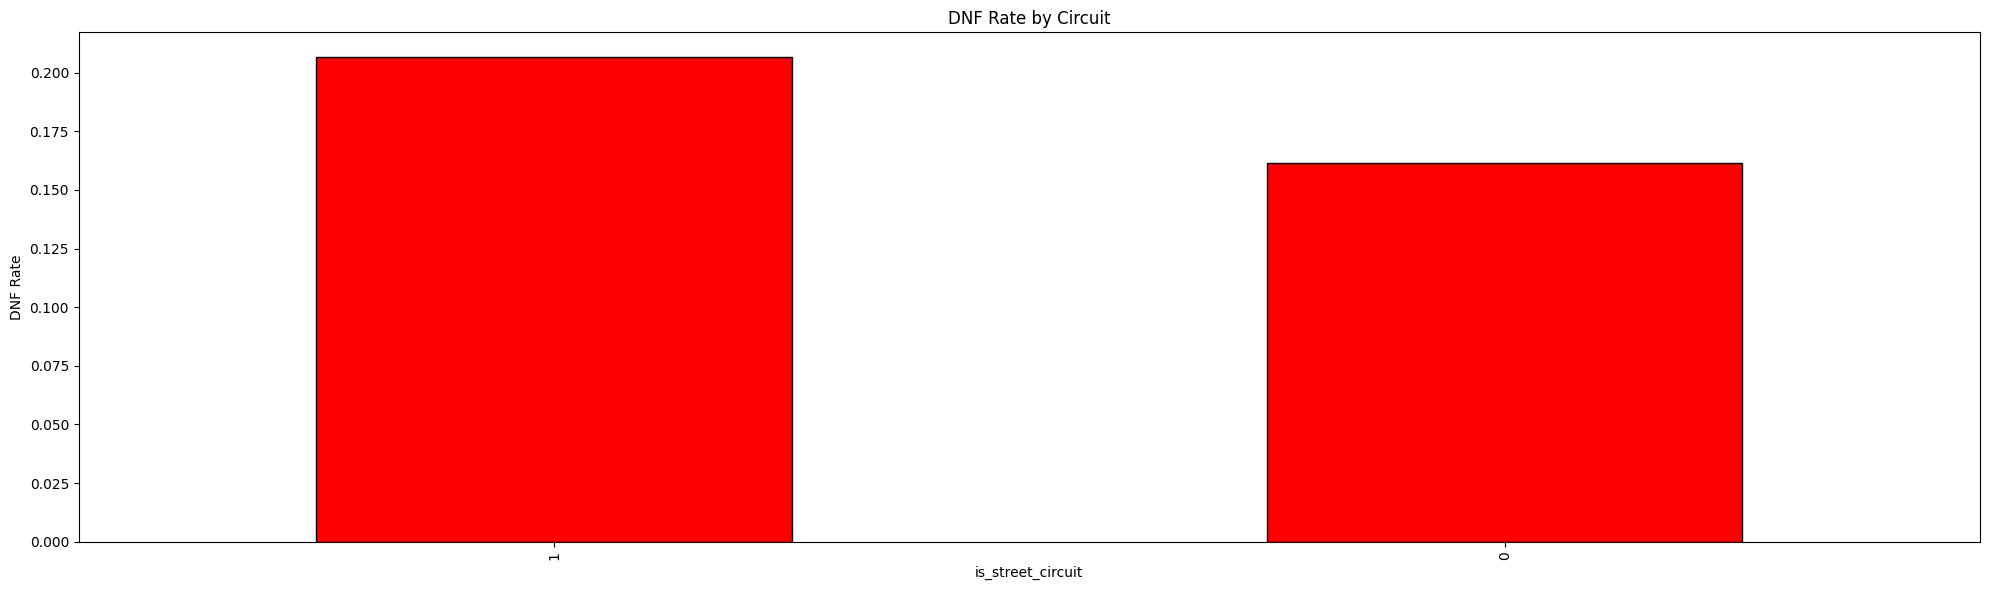

In [28]:
import matplotlib.pyplot as plt

df.groupby('is_street_circuit')['DNF'].mean().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(20, 6),
    title='DNF Rate by Circuit',
    color='red',
    edgecolor='black'
)
plt.xticks(rotation=90)
plt.ylabel('DNF Rate')
plt.tight_layout()
plt.show()

# 03 Feature Selection

### 03.01 FILL NA

In [29]:
qualifying_position_fill = df.groupby('raceId')['grid'].transform('max')
df['qualifying_position'] = df['qualifying_position'].fillna(qualifying_position_fill)

In [30]:
df['driver_championship_points'] = df['driver_championship_points'].fillna(0)
df['driver_championship_position'] = df['driver_championship_position'].fillna(df['driver_championship_position'].median())
df['driver_wins'] = df['driver_wins'].fillna(0)
# same for constructor  standings
df['constructor_championship_points'] = df['constructor_championship_points'].fillna(0)
df['constructor_championship_position'] = df['constructor_championship_position'].fillna(df['constructor_championship_position'].median())
df['constructor_wins'] = df['constructor_wins'].fillna(0)

In [31]:
features = [
    'grid',
    'qualifying_position', 
    'driver_championship_points',
    'driver_championship_position',
    'driver_wins',
    'constructor_championship_points',
    'constructor_championship_position',
    'constructor_wins',
    'year',
    'round',
    'driver_experience',
    'constructor_dnf_rate',
    'constructor_dnf_rate_last10',
    'constructor_dnf_rate_last5',
    'driver_dnf_rate',
    'driver_dnf_rate_last10',
    'driver_dnf_rate_last5',
    'circuit_dnf_rate',
    'is_street_circuit'
]

X = df[features]
y = df['DNF']

print(X.shape)
print(X.isnull().sum())

(4611, 19)
grid                                 0
qualifying_position                  0
driver_championship_points           0
driver_championship_position         0
driver_wins                          0
constructor_championship_points      0
constructor_championship_position    0
constructor_wins                     0
year                                 0
round                                0
driver_experience                    0
constructor_dnf_rate                 0
constructor_dnf_rate_last10          0
constructor_dnf_rate_last5           0
driver_dnf_rate                      0
driver_dnf_rate_last10               0
driver_dnf_rate_last5                0
circuit_dnf_rate                     0
is_street_circuit                    0
dtype: int64


In [32]:
X.describe()
X.head()

,grid,qualifying_position,driver_championship_points,driver_championship_position,driver_wins,constructor_championship_points,constructor_championship_position,constructor_wins,year,round,driver_experience,constructor_dnf_rate,constructor_dnf_rate_last10,constructor_dnf_rate_last5,driver_dnf_rate,driver_dnf_rate_last10,driver_dnf_rate_last5,circuit_dnf_rate,is_street_circuit
22145,1,1.0,0.0,19.0,0.0,25.0,2.0,1.0,2014,1,129,0.280000,0.280000,0.28,0.280000,0.280000,0.280000,0.280000,1
22149,1,1.0,25.0,2.0,1.0,68.0,1.0,2.0,2014,2,130,0.500000,0.500000,0.50,1.000000,1.000000,1.000000,1.000000,0
22171,2,2.0,50.0,2.0,2.0,111.0,1.0,3.0,2014,3,131,0.250000,0.250000,0.25,0.500000,0.500000,0.500000,0.500000,0
22193,1,1.0,75.0,2.0,3.0,154.0,1.0,4.0,2014,4,132,0.166667,0.166667,0.00,0.333333,0.333333,0.333333,0.333333,0
22215,1,1.0,100.0,1.0,4.0,197.0,1.0,5.0,2014,5,133,0.125000,0.125000,0.00,0.250000,0.250000,0.250000,0.250000,0


# 04 MODEL TRAINING

In [33]:
print(df['DNF'].value_counts(normalize=True))
print(df.shape)

DNF
0    0.829538
1    0.170462
Name: proportion, dtype: float64
(4611, 50)


In [34]:
train = df[df['year'] < 2022]
test = df[df['year'] >= 2022]

X_train = train[features]
y_train = train['DNF']

X_test = test[features]
y_test = test['DNF']

print("Train:", X_train.shape, "DNF rate:", y_train.mean().round(3))
print("Test:", X_test.shape, "DNF rate:", y_test.mean().round(3))

Train: (3257, 19) DNF rate: 0.183
Test: (1354, 19) DNF rate: 0.14


dummy model that does nothing but will provide a baseline for our model.

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline F1:", f1_score(y_test, baseline_pred))

Baseline Accuracy: 0.8604135893648449
Baseline F1: 0.0


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0: 1, 1: 20})
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))
print("\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6277695716395865
Random Forest F1: 0.26099706744868034

               precision    recall  f1-score   support

           0       0.88      0.65      0.75      1165
           1       0.18      0.47      0.26       189

    accuracy                           0.63      1354
   macro avg       0.53      0.56      0.51      1354
weighted avg       0.79      0.63      0.68      1354



Pushes weights for DNF till 30 as we need high recall and low precisison. 

In [37]:
from sklearn.metrics import f1_score
import numpy as np

rf_proba = rf.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    pred = (rf_proba >= t).astype(int)
    score = f1_score(y_test, pred)
    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)
print(f"Best F1: {max(f1_scores):.3f}")
best_pred = (rf_proba >= best_threshold).astype(int)
print("\nClassification Report at Best Threshold:")
print(classification_report(y_test, best_pred))

Best Threshold: 0.40000000000000013
Best F1: 0.268

Classification Report at Best Threshold:
              precision    recall  f1-score   support

           0       0.90      0.43      0.58      1165
           1       0.17      0.70      0.27       189

    accuracy                           0.47      1354
   macro avg       0.53      0.56      0.42      1354
weighted avg       0.80      0.47      0.54      1354



In [38]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale:.2f}")

xgb = XGBClassifier(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=6, scale_pos_weight=scale)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost F1:", f1_score(y_test, xgb_pred))


Scale pos weight: 4.46
XGBoost Accuracy: 0.7570162481536189
XGBoost F1: 0.18765432098765433


# 05 MODEL TRAINING USING CROSS VAL
small dataset so lets use Cross validation for xgboost and rf using randomizedsearchCV

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [4, 6, 8, 10, 15]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=0),
    param_grid,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=0
)

xgb_search.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)
print("Best XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("Best XGBoost F1:", f1_score(y_test, xgb_pred))


Best XGBoost Params: {'subsample': 0.6, 'scale_pos_weight': 10, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best XGBoost Accuracy: 0.22156573116691286
Best XGBoost F1: 0.2619047619047619


In [40]:
importance = pd.Series(
    xgb_search.best_estimator_.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

driver_championship_position         0.111732
constructor_championship_position    0.062751
constructor_championship_points      0.061583
round                                0.058659
driver_championship_points           0.057935
qualifying_position                  0.056933
circuit_dnf_rate                     0.054989
driver_wins                          0.054175
year                                 0.051474
constructor_dnf_rate_last10          0.049770
driver_experience                    0.047027
constructor_wins                     0.046873
driver_dnf_rate                      0.044948
grid                                 0.044908
driver_dnf_rate_last5                0.044879
driver_dnf_rate_last10               0.042477
is_street_circuit                    0.037350
constructor_dnf_rate                 0.036005
constructor_dnf_rate_last5           0.035532
dtype: float32


In [41]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.98      0.10      0.18      1165
           1       0.15      0.99      0.26       189

    accuracy                           0.22      1354
   macro avg       0.57      0.54      0.22      1354
weighted avg       0.87      0.22      0.19      1354



In [42]:
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    pred = (xgb_proba >= t).astype(int)
    score = f1_score(y_test, pred)
    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)
print(f"Best F1: {max(f1_scores):.3f}")
best_pred = (xgb_proba >= best_threshold).astype(int)
print("\nClassification Report at Best Threshold:")
print(classification_report(y_test, best_pred))

Best Threshold: 0.6000000000000002
Best F1: 0.274

Classification Report at Best Threshold:
              precision    recall  f1-score   support

           0       0.92      0.29      0.44      1165
           1       0.16      0.85      0.27       189

    accuracy                           0.37      1354
   macro avg       0.54      0.57      0.36      1354
weighted avg       0.82      0.37      0.42      1354



# 06 INVESTIGATE WHY THE MODEL IS STUCK AT F1 SCORE OF 0.279 

In [43]:
X_test.columns.tolist()

['grid',
 'qualifying_position',
 'driver_championship_points',
 'driver_championship_position',
 'driver_wins',
 'constructor_championship_points',
 'constructor_championship_position',
 'constructor_wins',
 'year',
 'round',
 'driver_experience',
 'constructor_dnf_rate',
 'constructor_dnf_rate_last10',
 'constructor_dnf_rate_last5',
 'driver_dnf_rate',
 'driver_dnf_rate_last10',
 'driver_dnf_rate_last5',
 'circuit_dnf_rate',
 'is_street_circuit']

In [44]:
results = X_test.copy()

results['actual'] = y_test.values
results['predicted'] = best_pred
results['probability'] = xgb_proba

results['constructor'] = df['constructor_name']
results['driver'] = df['driver_forename'] + ' ' + df['driver_surname']
results['year'] = df['year']
results['race'] = df['race_name']


results.head(30)

,grid,qualifying_position,driver_championship_points,driver_championship_position,driver_wins,constructor_championship_points,constructor_championship_position,constructor_wins,year,round,...,driver_dnf_rate_last10,driver_dnf_rate_last5,circuit_dnf_rate,is_street_circuit,actual,predicted,probability,constructor,driver,race
25402,5,5.0,15.0,3.0,0.0,27.0,2.0,0.0,2022,1,...,0.1,0.0,0.05,0,0,0,0.371630,Mercedes,Lewis Hamilton,Bahrain Grand Prix
25429,15,16.0,16.0,5.0,0.0,38.0,2.0,0.0,2022,2,...,0.1,0.0,0.05,1,0,1,0.609451,Mercedes,Lewis Hamilton,Saudi Arabian Grand Prix
25443,5,5.0,28.0,5.0,0.0,65.0,2.0,0.0,2022,3,...,0.0,0.0,0.05,1,0,0,0.590868,Mercedes,Lewis Hamilton,Australian Grand Prix
25472,14,13.0,28.0,7.0,0.0,77.0,3.0,0.0,2022,4,...,0.0,0.0,0.05,0,0,1,0.612902,Mercedes,Lewis Hamilton,Emilia Romagna Grand Prix
25485,6,6.0,36.0,6.0,0.0,95.0,3.0,0.0,2022,5,...,0.0,0.0,0.05,1,0,0,0.596187,Mercedes,Lewis Hamilton,Miami Grand Prix
25504,6,6.0,46.0,6.0,0.0,120.0,3.0,0.0,2022,6,...,0.0,0.0,0.05,0,0,0,0.595902,Mercedes,Lewis Hamilton,Spanish Grand Prix
25527,8,8.0,50.0,6.0,0.0,134.0,3.0,0.0,2022,7,...,0.0,0.0,0.05,1,0,1,0.606659,Mercedes,Lewis Hamilton,Monaco Grand Prix
25543,7,7.0,62.0,6.0,0.0,161.0,3.0,0.0,2022,8,...,0.0,0.0,0.05,1,0,1,0.604596,Mercedes,Lewis Hamilton,Azerbaijan Grand Prix
25562,4,4.0,77.0,6.0,0.0,188.0,3.0,0.0,2022,9,...,0.0,0.0,0.05,0,0,1,0.606842,Mercedes,Lewis Hamilton,Canadian Grand Prix
25582,5,5.0,93.0,6.0,0.0,204.0,3.0,0.0,2022,10,...,0.0,0.0,0.05,0,0,0,0.595613,Mercedes,Lewis Hamilton,British Grand Prix


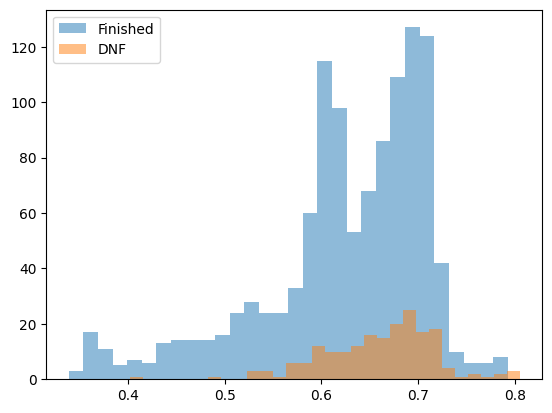

In [45]:
import matplotlib.pyplot as plt

plt.hist(xgb_proba[y_test==0], bins=30, alpha=0.5, label='Finished')
plt.hist(xgb_proba[y_test==1], bins=30, alpha=0.5, label='DNF')

plt.legend()
plt.show()

In [46]:
ham = results[results['driver'] == 'Lewis Hamilton']

print(ham['actual'].value_counts())

actual
0    62
1     6
Name: count, dtype: int64


In [47]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, xgb_proba)
print(auc)

0.6065013511365442


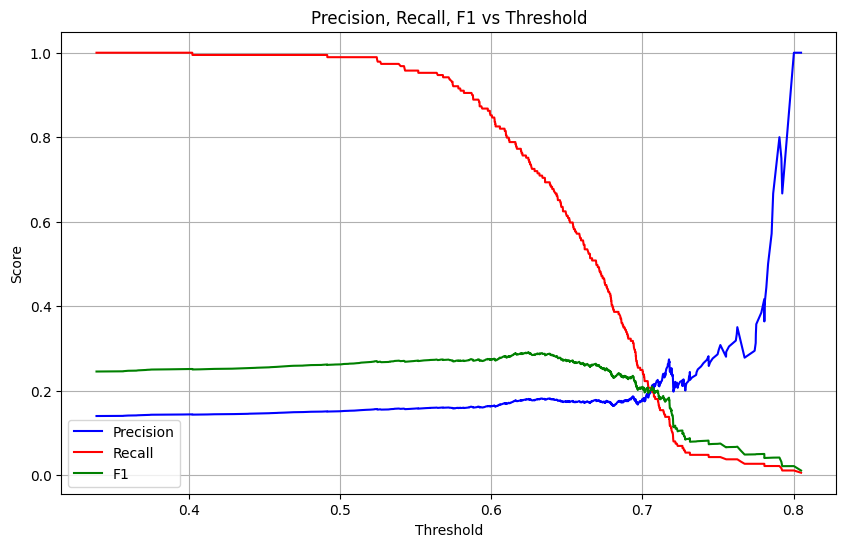

In [48]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

xgb_proba = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='red')
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
plt.plot(thresholds, f1, label='F1', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
best_pred = (xgb_proba >= 0.65).astype(int)
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.89      0.53      0.66      1165
           1       0.17      0.61      0.27       189

    accuracy                           0.54      1354
   macro avg       0.53      0.57      0.47      1354
weighted avg       0.79      0.54      0.61      1354



# **WE HIT THE DATA CEILING**

In [50]:
df.to_csv('../data/processed/f1_cleaned.csv', index=False)

In [51]:
import joblib

joblib.dump(xgb_search.best_estimator_, '../models/dnf_model.pkl')
print("Model saved!")

Model saved!


In [52]:
import joblib


xgb_dnf = joblib.load('../models/dnf_model.pkl')


dnf_features = ['grid',
 'qualifying_position',
 'driver_championship_points',
 'driver_championship_position',
 'driver_wins',
 'constructor_championship_points',
 'constructor_championship_position',
 'constructor_wins',
 'year',
 'round',
 'driver_experience',
 'constructor_dnf_rate',
 'constructor_dnf_rate_last10',
 'constructor_dnf_rate_last5',
 'driver_dnf_rate',
 'driver_dnf_rate_last10',
 'driver_dnf_rate_last5',
 'circuit_dnf_rate',
 'is_street_circuit']

df['dnf_probability'] = xgb_dnf.predict_proba(df[dnf_features])[:, 1]

print(df['dnf_probability'].describe())

count    4611.000000
mean        0.640731
std         0.089962
min         0.310084
25%         0.601039
50%         0.659403
75%         0.702899
max         0.838535
Name: dnf_probability, dtype: float64


In [53]:
# dnf_train.py — after finding best_xgb, add:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# train best_xgb on X_train only (re-run RandomizedSearchCV on X_train)
# then:
calibrated = CalibratedClassifierCV(best_xgb, cv=5, method='isotonic')
calibrated.fit(X_val, y_val)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...00169AE186210>, 

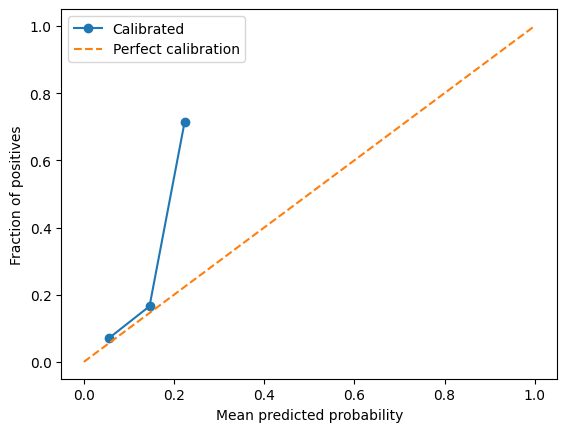

In [56]:
probs = calibrated.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Calibrated')
plt.plot([0,1],[0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.show()

In [57]:
import numpy as np

probs = calibrated.predict_proba(X)[:, 1]
bin_edges = np.linspace(0, 1, 11)
bin_indices = np.digitize(probs, bin_edges)

# how many samples in the high-probability bin?
for i in range(1, 11):
    mask = bin_indices == i
    n = mask.sum()
    if n > 0:
        actual_dnf_rate = y[mask].mean()
        print(f"Bin {i}: n={n}, mean_pred={probs[mask].mean():.3f}, actual_dnf_rate={actual_dnf_rate:.3f}")



Bin 1: n=709, mean_pred=0.053, actual_dnf_rate=0.072
Bin 2: n=3125, mean_pred=0.162, actual_dnf_rate=0.158
Bin 3: n=508, mean_pred=0.246, actual_dnf_rate=0.287
Bin 4: n=196, mean_pred=0.334, actual_dnf_rate=0.311
Bin 5: n=34, mean_pred=0.460, actual_dnf_rate=0.382
Bin 6: n=26, mean_pred=0.535, actual_dnf_rate=0.500
Bin 7: n=13, mean_pred=0.660, actual_dnf_rate=0.615


In [58]:
joblib.dump(calibrated, "../models/dnf_model_calibrated1.pkl")

['../models/dnf_model_calibrated1.pkl']